# Лабораторна 1. Загальний пайплайн навчання.

В цій лабораторній роботі студенти тренують моделі машинного навчання
на базі простих регресій: лінійна, логістична, поліноміальна.
Ознайомлюються з базовими поняттями: спліт та  нормалізація даних, захист протікання даних (data leakage),
чистка, логування.

Працюємо в Google Colab.


## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [11]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [12]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [13]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі ПІСЛЯ, викликаючи `set_seed()`. Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [14]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)

set_seed()
print("Seed зафіксовано:", SEED)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ
# окремим генеруванням, не один раз на обидва


Seed зафіксовано: 42


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [10]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [6]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [9]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [15]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [16]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print("ndim identity:", identity.ndim)
print("ndim random_ints:", random_ints.ndim)

ndim identity: 2
ndim random_ints: 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [17]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [18]:
arr = np.arange(1, 13)

matrix = arr.reshape((3, 4))
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [19]:
df = pd.DataFrame({
    "name": ["Олена", "Іван", "Марія", "Петро", "Анна"],
    "score": [85, 72, 92, 65, 88]
})

top = df[df["score"] > 80].sort_values(by="score", ascending=False)
print(top)


    name  score
2  Марія     92
4   Анна     88
0  Олена     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [20]:
df["grade"] = df["score"].apply(lambda x: "A" if x >= 90 else ("B" if x >= 75 else "C"))
print(df)

    name  score grade
0  Олена     85     B
1   Іван     72     C
2  Марія     92     A
3  Петро     65     C
4   Анна     88     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [21]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7.0)

print(zeros_t, zeros_t.shape, zeros_t.dtype)
print(sevens_t, sevens_t.shape, sevens_t.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3]) torch.float32
tensor([[7., 7., 7.],
        [7., 7., 7.]]) torch.Size([2, 3]) torch.float32


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [22]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [23]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print("from_list:", from_list.shape, from_list.dtype, from_list.ndim)
print("random_t:", random_t.shape, random_t.dtype, random_t.ndim)

from_list: torch.Size([2, 2]) torch.int64 2
random_t: torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [24]:
n = 5.0
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print(f"x.grad: {x.grad.item()}")
print(f"Аналітичний: {2 * n}")

x.grad: 10.0
Аналітичний: 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [25]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for _ in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

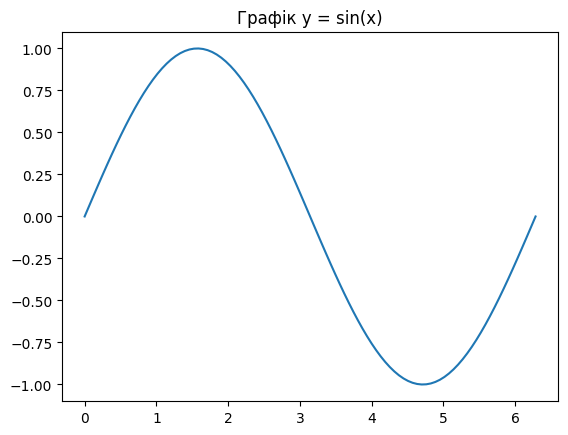

In [26]:
xs = np.linspace(0, 2*np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.title("Графік y = sin(x)")
plt.show()

**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

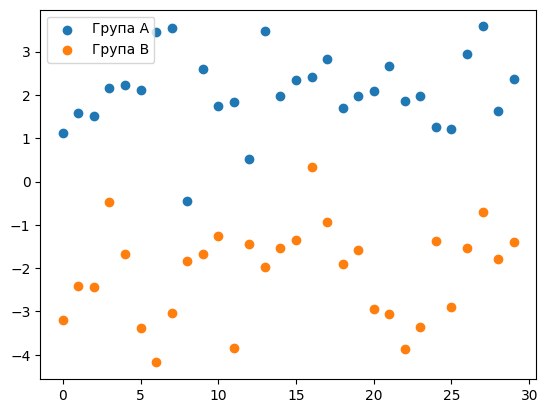

In [27]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.scatter(range(30), group_a, color="C0", label="Група A")
plt.scatter(range(30), group_b, color="C1", label="Група B")
plt.legend()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [28]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

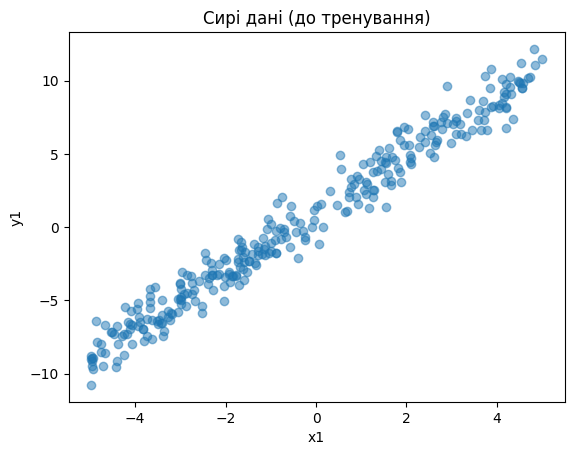

In [29]:
plt.scatter(x1.numpy(), y1.numpy(), alpha=0.5)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15) — простий зріз тензора за індексами, без `Dataset`/`DataLoader`. Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [30]:
indices = torch.randperm(TASK1_N)
x1_shuffled = x1[indices]
y1_shuffled = y1[indices]

train_size = int(0.7 * TASK1_N)
val_size = int(0.15 * TASK1_N)

x_train1 = x1_shuffled[:train_size]
y_train1 = y1_shuffled[:train_size]

x_val1 = x1_shuffled[train_size : train_size + val_size]
y_val1 = y1_shuffled[train_size : train_size + val_size]

x_test1 = x1_shuffled[train_size + val_size :]
y_test1 = y1_shuffled[train_size + val_size :]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")

train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [31]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


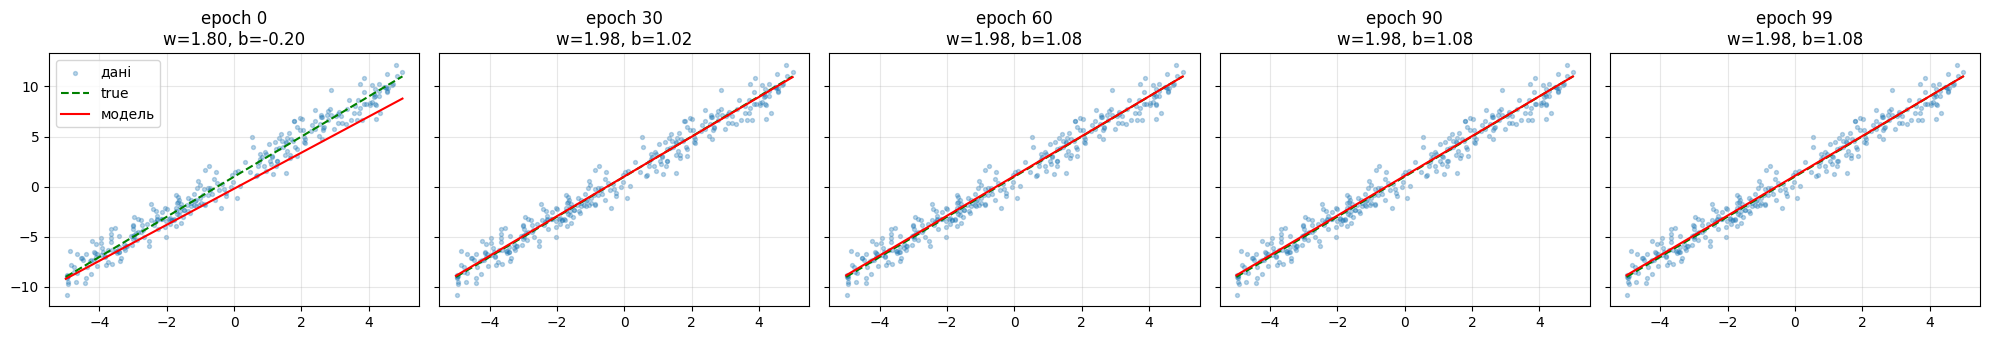

In [32]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом (за зразком Завдання 1) і натренуй лінійну регресію
за тим самим патерном — спліт, цикл навчання, перевірка на test. Організуй код тренування у логічні перевикористовувані функції.

Сценарій: Залежність між кількістю годин сну (x) та рівнем продуктивності на роботі у відсотках (y).
Параметри: $w = 8.0$ (кожна година сну додає приблизно 8% до продуктивності), $b = 10.0$ (базовий рівень продуктивності без нормального сну).

In [33]:
# Генерація даних
W_MY = 8.0
B_MY = 10.0
N_MY = 200

# Години сну від 3 до 10
x_my = torch.empty(N_MY, 1).uniform_(3, 10)
noise_my = 3.0 * torch.randn(N_MY, 1)
y_my = W_MY * x_my + B_MY + noise_my

# Збереження у CSV
import pandas as pd
df_my = pd.DataFrame({"sleep_hours": x_my.squeeze().numpy(), "productivity": y_my.squeeze().numpy()})
df_my.to_csv("dataset.csv", index=False)

# Спліт даних
indices = torch.randperm(N_MY)
x_my_train, y_my_train = x_my[indices][:140], y_my[indices][:140]
x_my_test, y_my_test = x_my[indices][140:], y_my[indices][140:]

# Тренування
my_model = torch.nn.Linear(1, 1)
optimizer = torch.optim.SGD(my_model.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

def train_model(model, x, y, epochs=100):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
    return model

my_model = train_model(my_model, x_my_train, y_my_train)

# Перевірка на test
with torch.no_grad():
    test_loss = loss_fn(my_model(x_my_test), y_my_test)
print(f"Test Loss: {test_loss.item():.4f}, w={my_model.weight.item():.2f}, b={my_model.bias.item():.2f}")

Test Loss: 20.1895, w=9.04, b=3.05


**Вправа 21.** Візьми свій пайплайн із з Вправи 20 і
розшир його до **поліноміальної** та **логістичної** регресії:

- **Поліноміальна регресія**: додай ознаки $x^2$, $x^3$ (об'єднай через
  `torch.cat`, наприклад `torch.cat([x, x**2, x**3], dim=1)`), модель тепер
  `nn.Linear(3, 1)` замість `nn.Linear(1, 1)`. MSE-loss і цикл навчання
  лишаються без змін.
- **Логістична регресія**: зміни задачу на класифікацію (два класи), заміни
  `nn.MSELoss()` на [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)
  — вихід моделі тепер логіт, а не пряме передбачення. Метрика — accuracy
  (`(torch.sigmoid(logits) > 0.5)`), а не MSE.

Навчи модель на своїх або
нових даних.

In [34]:
# ==========================================
# 1. ПОЛІНОМІАЛЬНА РЕГРЕСІЯ
# ==========================================
# Генеруємо нелінійні дані (наприклад, кубічну залежність)
N_POLY = 300
x_poly = torch.empty(N_POLY, 1).uniform_(-3, 3)
# y = 2*x^3 - 1.5*x^2 + 0.5*x + 2 + шум
y_poly = 2 * x_poly**3 - 1.5 * x_poly**2 + 0.5 * x_poly + 2.0 + torch.randn(N_POLY, 1)

# Створюємо ознаки x, x^2, x^3
x_poly_features = torch.cat([x_poly, x_poly**2, x_poly**3], dim=1)

# Модель тепер приймає 3 ознаки
poly_model = torch.nn.Linear(3, 1)
# Зменшуємо learning rate (lr), бо кубічні ознаки можуть давати великі градієнти
optimizer_poly = torch.optim.SGD(poly_model.parameters(), lr=0.001)
loss_fn_poly = torch.nn.MSELoss()

# Цикл навчання
for epoch in range(500):
    optimizer_poly.zero_grad()
    y_pred_poly = poly_model(x_poly_features)
    loss_poly = loss_fn_poly(y_pred_poly, y_poly)
    loss_poly.backward()
    optimizer_poly.step()

print(f"Поліноміальна регресія натренована. Останній Loss: {loss_poly.item():.4f}")

# ==========================================
# 2. ЛОГІСТИЧНА РЕГРЕСІЯ (Класифікація)
# ==========================================
# Генеруємо дані для 2 класів (наприклад, здав іспит / не здав залежно від годин підготовки)
N_LOG = 300
x_log = torch.empty(N_LOG, 1).uniform_(-5, 5)
# Клас 1, якщо значення більше 0 (з додаванням шуму для реалістичності), інакше 0
y_log = (x_log + torch.randn(N_LOG, 1) * 2.0 > 0).float()

log_model = torch.nn.Linear(1, 1)
optimizer_log = torch.optim.SGD(log_model.parameters(), lr=0.1)
# Використовуємо BCEWithLogitsLoss для класифікації
loss_fn_log = torch.nn.BCEWithLogitsLoss()

# Цикл навчання
for epoch in range(200):
    optimizer_log.zero_grad()
    logits = log_model(x_log)
    loss_log = loss_fn_log(logits, y_log)
    loss_log.backward()
    optimizer_log.step()

# Рахуємо Accuracy
with torch.no_grad():
    logits_pred = log_model(x_log)
    # Застосовуємо сигмоїду і поріг 0.5 для визначення класу
    preds = (torch.sigmoid(logits_pred) > 0.5).float()
    accuracy = (preds == y_log).float().mean()

print(f"Логістична регресія натренована. Accuracy: {accuracy.item() * 100:.2f}%")

Поліноміальна регресія натренована. Останній Loss: 1.4613
Логістична регресія натренована. Accuracy: 82.67%


In [35]:
import os

model_path = os.path.join(ARTIFACT_DIR, "model.pt")

# Зберігаємо ваги моделі (тут my_model — це модель з Вправи 20:)
torch.save(my_model.state_dict(), model_path)
print(f"Модель успішно збережена за шляхом: {model_path}")

Модель успішно збережена за шляхом: /content/drive/MyDrive/ai_systems/lab1/model.pt
